In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add scripts directory to path for imports
script_dir = Path('.').resolve()
project_root = script_dir.parent.parent.parent
sys.path.insert(0, str(project_root / 'src' / 'scripts'))

# Import loader
from loader_ir import (
    load_all_ir_data, 
    print_data_summary,
    apply_baseline_correction,
    PLASTIC_TYPES,
    CONTAMINANTS
)

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    hamming_loss,
    ConfusionMatrixDisplay
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load IR Spectral Data

In [2]:
# Define data path
raw_data_dir = project_root / 'data' / 'flattened_IR_data' / 'raw'

print(f"Project root: {project_root}")
print(f"Loading data from: {raw_data_dir}")
print()

# Load all IR data
data = load_all_ir_data(str(raw_data_dir), verbose=True)

Project root: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file
Loading data from: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Found 788 CSV files in C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Wavenumber resolution distribution:
  - 7469 points: 532 files (reference)
  - 1869 points: 256 files

Reference wavenumber range: 399.7 - 4000.2 cm^-1
Number of wavenumber points: 7469

Successfully loaded 788 spectra
Interpolated 256 files to match reference resolution (7469 points)


In [3]:
# Print data summary
print_data_summary(data)


DATA SUMMARY

Spectral Data:
  - Number of samples: 788
  - Number of wavenumber points: 7469
  - Wavenumber range: 399.7 - 4000.2 cm^-1

Plastic Type Distribution:
  - PP: 172 samples
  - LDPE: 188 samples
  - LLDPE: 190 samples
  - HDPE: 238 samples

Contaminant Distribution:
  - BSA: 404 samples
  - Oil: 418 samples
  - Starch: 360 samples
  - CMC: 314 samples
  - Guar: 400 samples
  - Casein: 30 samples

Samples by number of contaminants:
  - 0 contaminants: 90 samples
  - 1 contaminants: 128 samples
  - 2 contaminants: 224 samples
  - 3 contaminants: 104 samples
  - 4 contaminants: 172 samples
  - 5 contaminants: 70 samples



In [4]:
# Extract key arrays
wavenumbers = data['wavenumbers']
spectra = data['spectra']
plastic_labels = data['plastic_labels']  # One-hot encoded (n_samples, 4)
contaminant_labels = data['contaminant_labels']  # Multi-hot encoded (n_samples, 6)
filenames = data['filenames']
plastic_types = data['plastic_types']  # String labels
contaminants_list = data['contaminants_list']  # List of contaminant lists

print(f"Spectra shape: {spectra.shape}")
print(f"  - {spectra.shape[0]} samples")
print(f"  - {spectra.shape[1]} features (wavenumber points)")
print(f"\nWavenumber range: {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm⁻¹")
print(f"\nPlastic labels shape: {plastic_labels.shape}")
print(f"Contaminant labels shape: {contaminant_labels.shape}")

Spectra shape: (788, 7469)
  - 788 samples
  - 7469 features (wavenumber points)

Wavenumber range: 399.7 - 4000.2 cm⁻¹

Plastic labels shape: (788, 4)
Contaminant labels shape: (788, 6)


## 2. Data Preprocessing

In [5]:
# Apply baseline correction
spectra_corrected = apply_baseline_correction(
    spectra, 
    wavenumbers, 
    method='rubberband',
    verbose=True
)

print(f"\nCorrected spectra shape: {spectra_corrected.shape}")

Applying rubberband baseline correction to 788 spectra...
  Processed 50/788 spectra
  Processed 100/788 spectra
  Processed 150/788 spectra
  Processed 200/788 spectra
  Processed 250/788 spectra
  Processed 300/788 spectra
  Processed 350/788 spectra
  Processed 400/788 spectra
  Processed 450/788 spectra
  Processed 500/788 spectra
  Processed 550/788 spectra
  Processed 600/788 spectra
  Processed 650/788 spectra
  Processed 700/788 spectra
  Processed 750/788 spectra
Baseline correction complete.

Corrected spectra shape: (788, 7469)


In [6]:
# Prepare feature matrix (X) and target variables
X = spectra_corrected

# Convert one-hot plastic labels to single class labels
y_plastic = np.argmax(plastic_labels, axis=1)

# Contaminant labels remain as multi-hot for multi-label classification
y_contaminant = contaminant_labels

print(f"Feature matrix X shape: {X.shape}")
print(f"Plastic type labels y_plastic shape: {y_plastic.shape}")
print(f"Contaminant labels y_contaminant shape: {y_contaminant.shape}")

# Show class distribution
print(f"\nPlastic type distribution:")
unique, counts = np.unique(y_plastic, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {PLASTIC_TYPES[u]}: {c} samples")

Feature matrix X shape: (788, 7469)
Plastic type labels y_plastic shape: (788,)
Contaminant labels y_contaminant shape: (788, 6)

Plastic type distribution:
  PP: 172 samples
  LDPE: 188 samples
  LLDPE: 190 samples
  HDPE: 238 samples


In [7]:
# Split data into training and test sets
# Use a single split to ensure plastic and contaminant labels stay aligned
X_train, X_test, y_plastic_train, y_plastic_test, y_contaminant_train, y_contaminant_test = train_test_split(
    X, y_plastic, y_contaminant,
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y_plastic
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 630 samples
Test set: 158 samples


In [8]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training data mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training data std: {X_train_scaled.std():.6f}")

Scaled training data mean: -0.000000
Scaled training data std: 0.999866


## 2.1 Principal Component Analysis (PCA)

PRINCIPAL COMPONENT ANALYSIS (PCA)

Total features (wavenumber points): 7469

Explained variance by top components:
  PC1: 50.84% (cumulative: 50.84%)
  PC2: 23.06% (cumulative: 73.90%)
  PC3: 11.46% (cumulative: 85.36%)
  PC4: 4.93% (cumulative: 90.29%)
  PC5: 3.03% (cumulative: 93.32%)
  PC6: 2.21% (cumulative: 95.54%)
  PC7: 1.59% (cumulative: 97.12%)
  PC8: 0.82% (cumulative: 97.94%)
  PC9: 0.61% (cumulative: 98.56%)
  PC10: 0.37% (cumulative: 98.93%)

Components needed for 95% variance: 6
Components needed for 99% variance: 11


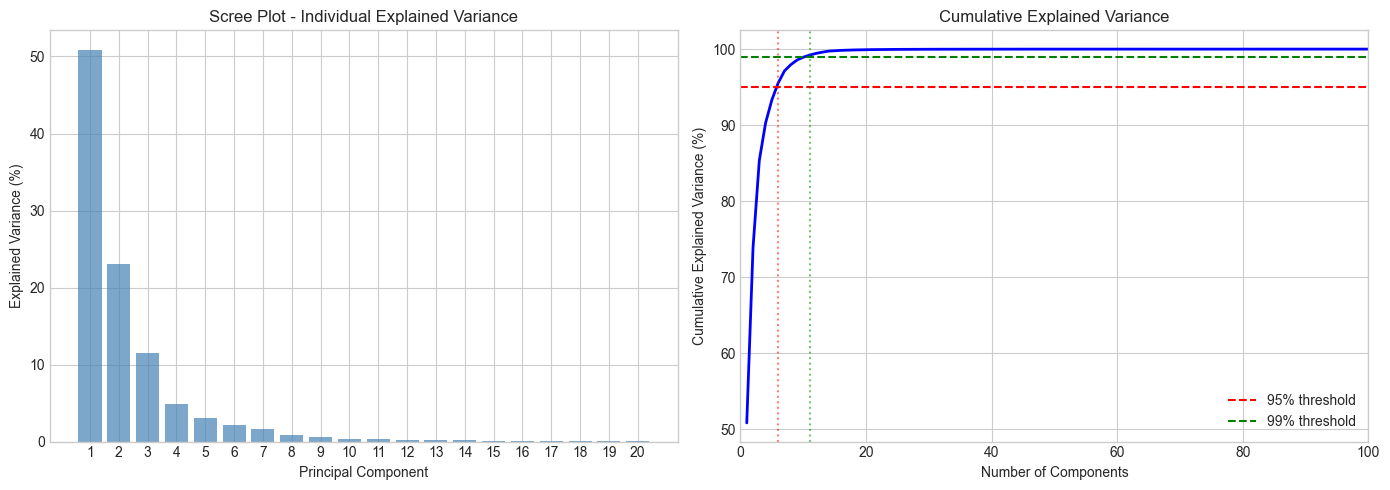

In [9]:
from sklearn.decomposition import PCA

# Perform PCA on the full scaled dataset
# First, scale all data (not just training)
X_all_scaled = scaler.fit_transform(X)

# Fit PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_all_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components needed for different variance thresholds
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print("=" * 60)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 60)
print(f"\nTotal features (wavenumber points): {X.shape[1]}")
print(f"\nExplained variance by top components:")
for i in range(min(10, len(pca_full.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}% (cumulative: {cumulative_variance[i]*100:.2f}%)")

print(f"\nComponents needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scree plot (individual variance)
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot - Individual Explained Variance')
axes[0].set_xticks(range(1, 21))

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 'b-', linewidth=2)
axes[1].axhline(y=95, color='r', linestyle='--', label='95% threshold')
axes[1].axhline(y=99, color='g', linestyle='--', label='99% threshold')
axes[1].axvline(x=n_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_99, color='g', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_xlim([0, min(100, len(cumulative_variance))])

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_pca_variance.png', dpi=150)
plt.show()

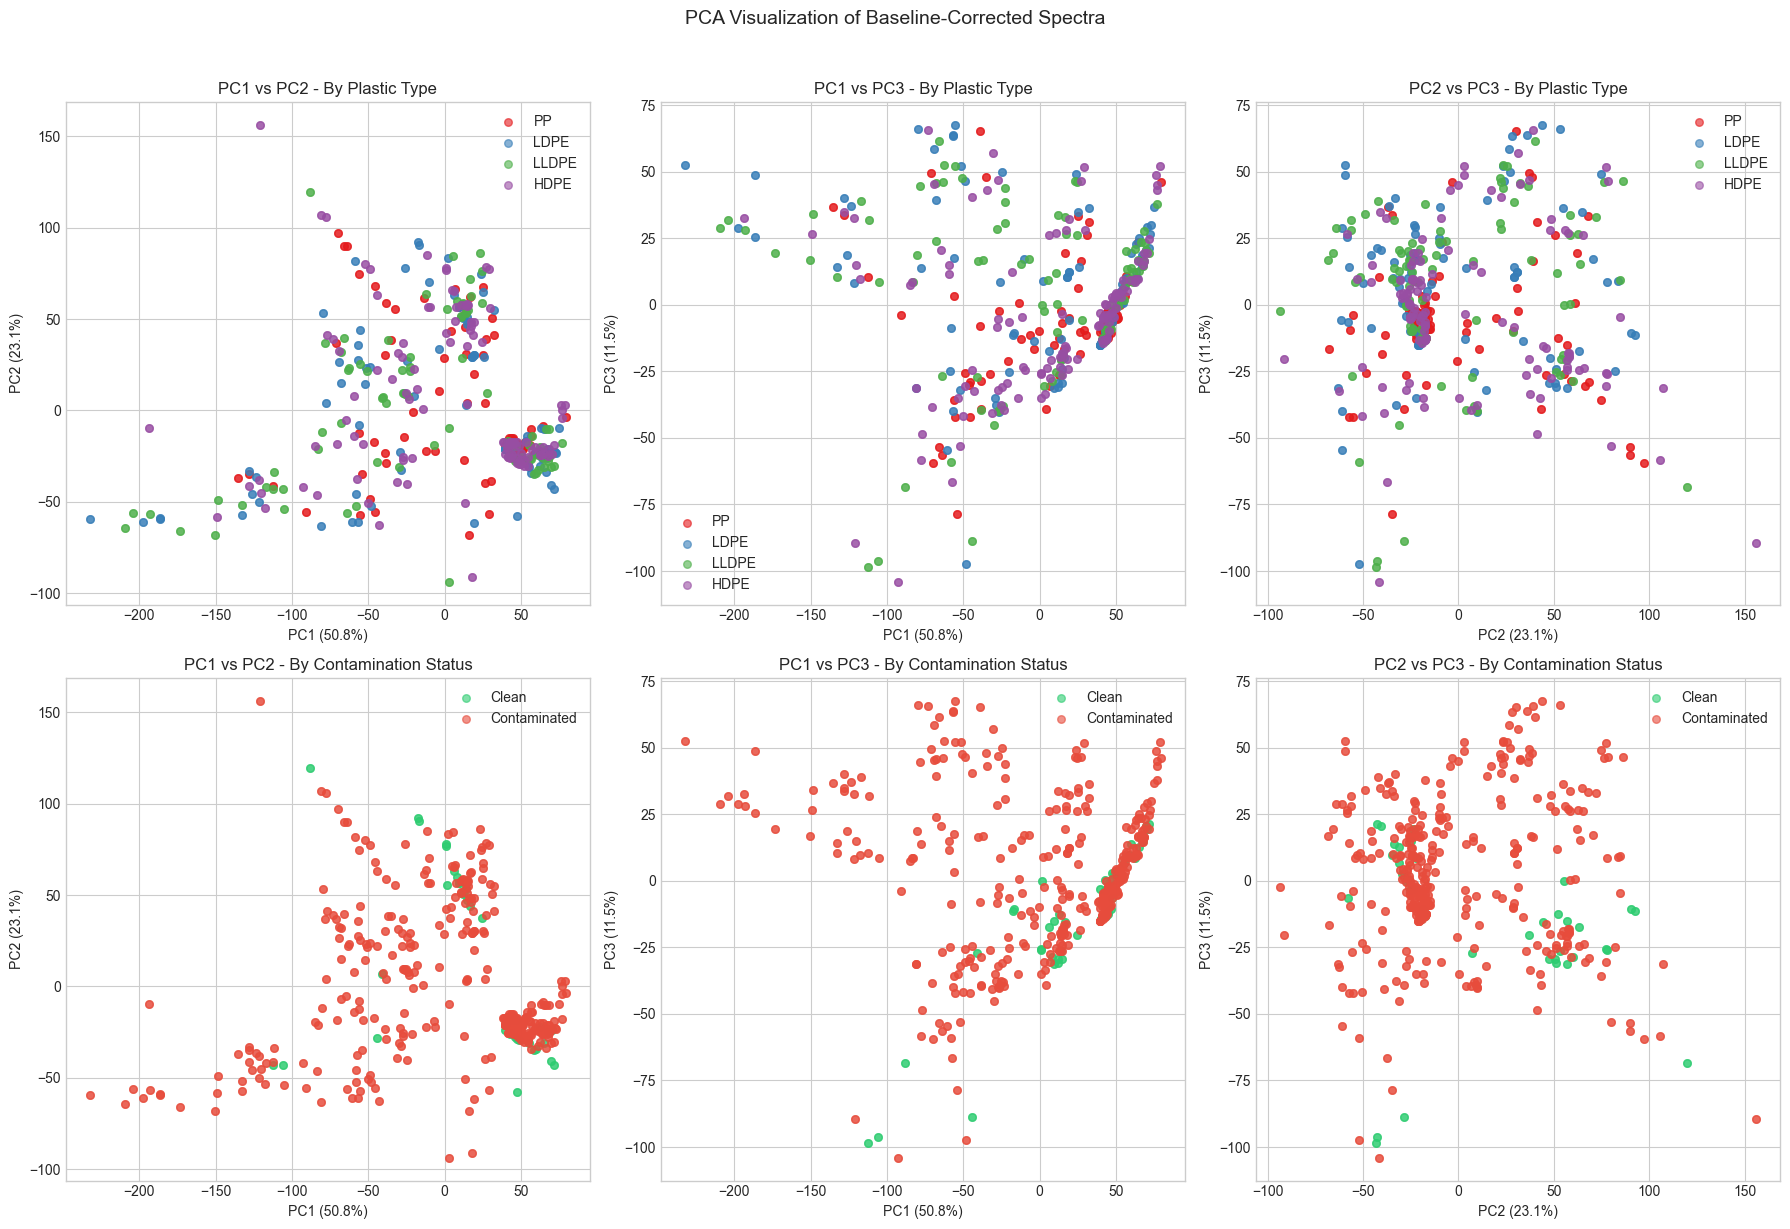


PCA Summary:
  Clean samples: 90
  Contaminated samples: 698


In [10]:
# Visualize data in PCA space (first 2-3 components)
# Transform data to PCA space
pca_3d = PCA(n_components=3)
X_pca = pca_3d.fit_transform(X_all_scaled)

# Create scatter plots colored by plastic type and contaminants
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: PC1 vs PC2, PC1 vs PC3, PC2 vs PC3 - colored by plastic type
colors_plastic = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  # Red, Blue, Green, Purple
for i, plastic in enumerate(PLASTIC_TYPES):
    mask = y_plastic == i
    axes[0, 0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_plastic[i], 
                       label=plastic, alpha=0.6, s=30)
    axes[0, 1].scatter(X_pca[mask, 0], X_pca[mask, 2], c=colors_plastic[i], 
                       label=plastic, alpha=0.6, s=30)
    axes[0, 2].scatter(X_pca[mask, 1], X_pca[mask, 2], c=colors_plastic[i], 
                       label=plastic, alpha=0.6, s=30)

axes[0, 0].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 0].set_title('PC1 vs PC2 - By Plastic Type')
axes[0, 0].legend()

axes[0, 1].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 1].set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
axes[0, 1].set_title('PC1 vs PC3 - By Plastic Type')
axes[0, 1].legend()

axes[0, 2].set_xlabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 2].set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
axes[0, 2].set_title('PC2 vs PC3 - By Plastic Type')
axes[0, 2].legend()

# Row 2: Colored by contamination status (clean vs contaminated)
has_contaminant = y_contaminant.sum(axis=1) > 0
colors_contam = ['#2ecc71', '#e74c3c']  # Green for clean, Red for contaminated
labels_contam = ['Clean', 'Contaminated']

for i, (has_cont, label) in enumerate(zip([False, True], labels_contam)):
    mask = has_contaminant == has_cont
    axes[1, 0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_contam[i], 
                       label=label, alpha=0.6, s=30)
    axes[1, 1].scatter(X_pca[mask, 0], X_pca[mask, 2], c=colors_contam[i], 
                       label=label, alpha=0.6, s=30)
    axes[1, 2].scatter(X_pca[mask, 1], X_pca[mask, 2], c=colors_contam[i], 
                       label=label, alpha=0.6, s=30)

axes[1, 0].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 0].set_title('PC1 vs PC2 - By Contamination Status')
axes[1, 0].legend()

axes[1, 1].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
axes[1, 1].set_title('PC1 vs PC3 - By Contamination Status')
axes[1, 1].legend()

axes[1, 2].set_xlabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 2].set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
axes[1, 2].set_title('PC2 vs PC3 - By Contamination Status')
axes[1, 2].legend()

plt.suptitle('PCA Visualization of Baseline-Corrected Spectra', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_pca_scatter.png', dpi=150)
plt.show()

print(f"\nPCA Summary:")
print(f"  Clean samples: {(~has_contaminant).sum()}")
print(f"  Contaminated samples: {has_contaminant.sum()}")

C:\Users\Mikey\AppData\Local\Temp\ipykernel_29948\1681799313.py:27: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_29948\1681799313.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_pca_loadings.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


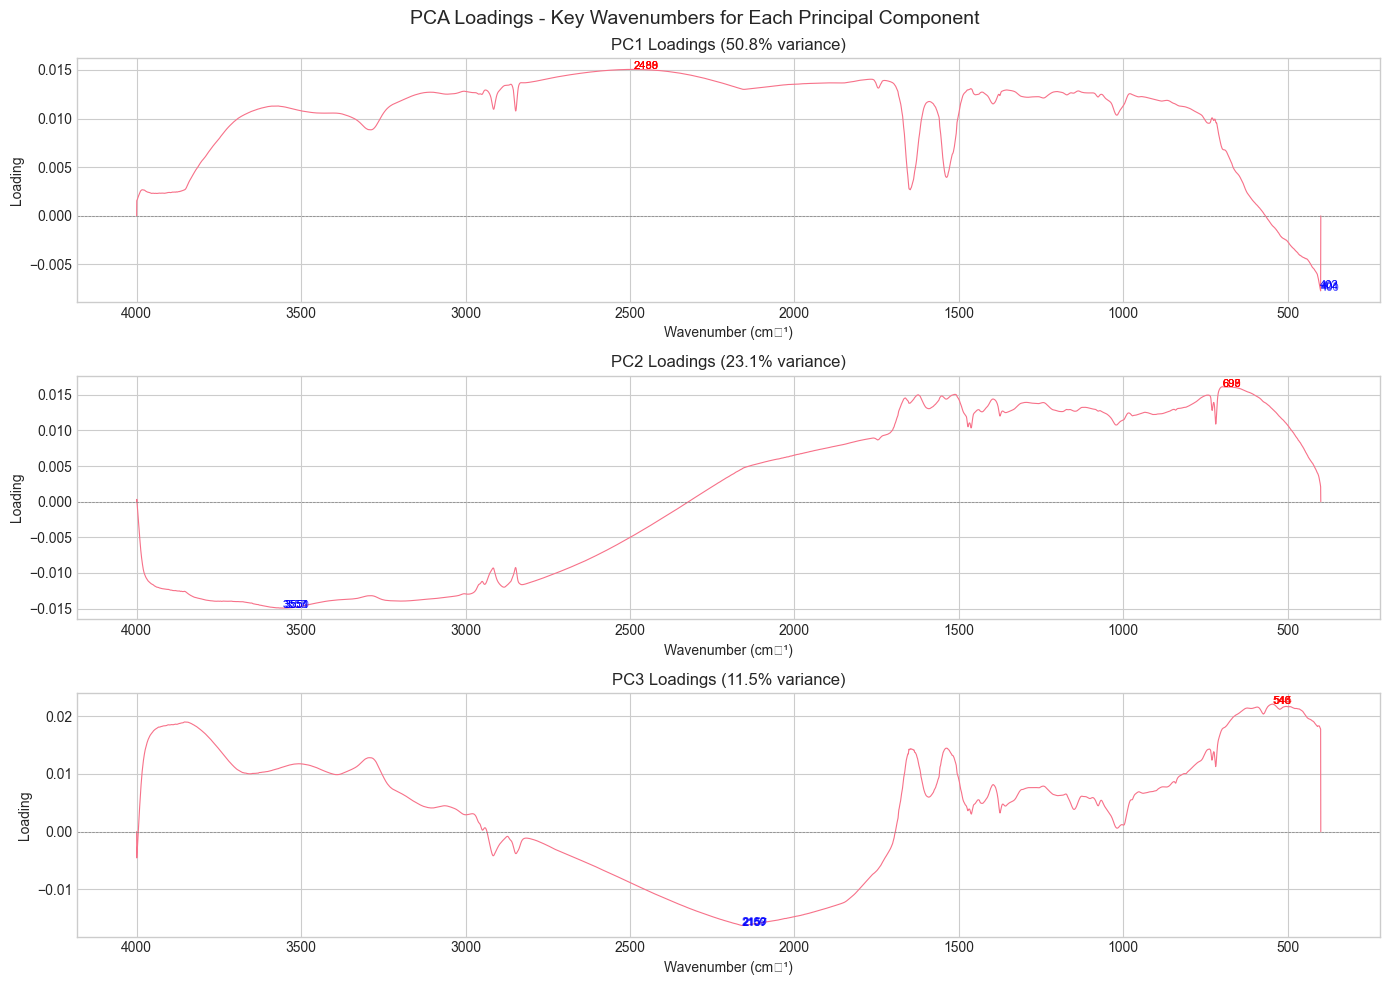


TOP CONTRIBUTING WAVENUMBERS BY PRINCIPAL COMPONENT

PC1 (50.8% variance):
----------------------------------------
   1.  2489.2 cm⁻¹ (+0.0150)
   2.  2488.7 cm⁻¹ (+0.0150)
   3.  2488.2 cm⁻¹ (+0.0150)
   4.  2489.7 cm⁻¹ (+0.0150)
   5.  2487.8 cm⁻¹ (+0.0150)
   6.  2490.2 cm⁻¹ (+0.0150)
   7.  2490.7 cm⁻¹ (+0.0150)
   8.  2487.3 cm⁻¹ (+0.0150)
   9.  2491.1 cm⁻¹ (+0.0150)
  10.  2486.8 cm⁻¹ (+0.0150)

PC2 (23.1% variance):
----------------------------------------
   1.   698.1 cm⁻¹ (+0.0161)
   2.   697.6 cm⁻¹ (+0.0161)
   3.   698.6 cm⁻¹ (+0.0161)
   4.   697.2 cm⁻¹ (+0.0161)
   5.   699.1 cm⁻¹ (+0.0161)
   6.   696.7 cm⁻¹ (+0.0161)
   7.   699.6 cm⁻¹ (+0.0161)
   8.   696.2 cm⁻¹ (+0.0161)
   9.   700.0 cm⁻¹ (+0.0161)
  10.   695.7 cm⁻¹ (+0.0161)

PC3 (11.5% variance):
----------------------------------------
   1.   545.8 cm⁻¹ (+0.0221)
   2.   545.3 cm⁻¹ (+0.0221)
   3.   544.8 cm⁻¹ (+0.0221)
   4.   546.2 cm⁻¹ (+0.0221)
   5.   544.3 cm⁻¹ (+0.0221)
   6.   546.7 cm⁻¹ (+0.0221)
 

In [11]:
# Visualize PCA loadings (which wavenumbers contribute most to each PC)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, ax in enumerate(axes):
    loadings = pca_3d.components_[i]
    ax.plot(wavenumbers, loadings, linewidth=0.8)
    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.set_ylabel('Loading')
    ax.set_title(f'PC{i+1} Loadings ({pca_3d.explained_variance_ratio_[i]*100:.1f}% variance)')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.invert_xaxis()
    
    # Mark top 5 positive and negative loadings
    top_pos_idx = np.argsort(loadings)[-5:]
    top_neg_idx = np.argsort(loadings)[:5]
    
    for idx in top_pos_idx:
        ax.annotate(f'{wavenumbers[idx]:.0f}', 
                   xy=(wavenumbers[idx], loadings[idx]),
                   fontsize=8, color='red', alpha=0.7)
    for idx in top_neg_idx:
        ax.annotate(f'{wavenumbers[idx]:.0f}', 
                   xy=(wavenumbers[idx], loadings[idx]),
                   fontsize=8, color='blue', alpha=0.7)

plt.suptitle('PCA Loadings - Key Wavenumbers for Each Principal Component', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_pca_loadings.png', dpi=150)
plt.show()

# Print top contributing wavenumbers for each PC
print("\n" + "=" * 60)
print("TOP CONTRIBUTING WAVENUMBERS BY PRINCIPAL COMPONENT")
print("=" * 60)

for i in range(3):
    loadings = pca_3d.components_[i]
    top_idx = np.argsort(np.abs(loadings))[-10:][::-1]
    
    print(f"\nPC{i+1} ({pca_3d.explained_variance_ratio_[i]*100:.1f}% variance):")
    print("-" * 40)
    for rank, idx in enumerate(top_idx, 1):
        direction = "+" if loadings[idx] > 0 else "-"
        print(f"  {rank:2d}. {wavenumbers[idx]:7.1f} cm⁻¹ ({direction}{abs(loadings[idx]):.4f})")

## 3. Logistic Regression for Plastic Type Classification

In [12]:
# Create and train logistic regression model for plastic type
lr_plastic = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=5000,
    random_state=RANDOM_STATE,
    C=100.0  # Regularization strength
)

print("Training Logistic Regression for Plastic Type Classification...")
lr_plastic.fit(X_train_scaled, y_plastic_train)
print("Training complete!")

Training Logistic Regression for Plastic Type Classification...


c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete!


In [13]:
# Predictions on test set
y_plastic_pred = lr_plastic.predict(X_test_scaled)

# Evaluate plastic type classification
print("=" * 60)
print("PLASTIC TYPE CLASSIFICATION RESULTS")
print("=" * 60)

# Accuracy
accuracy_plastic = accuracy_score(y_plastic_test, y_plastic_pred)
print(f"\nAccuracy: {accuracy_plastic:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_plastic_test, y_plastic_pred, target_names=PLASTIC_TYPES))

PLASTIC TYPE CLASSIFICATION RESULTS

Accuracy: 0.9620

Classification Report:
              precision    recall  f1-score   support

          PP       1.00      1.00      1.00        34
        LDPE       1.00      0.95      0.97        38
       LLDPE       0.90      0.95      0.92        38
        HDPE       0.96      0.96      0.96        48

    accuracy                           0.96       158
   macro avg       0.96      0.96      0.96       158
weighted avg       0.96      0.96      0.96       158



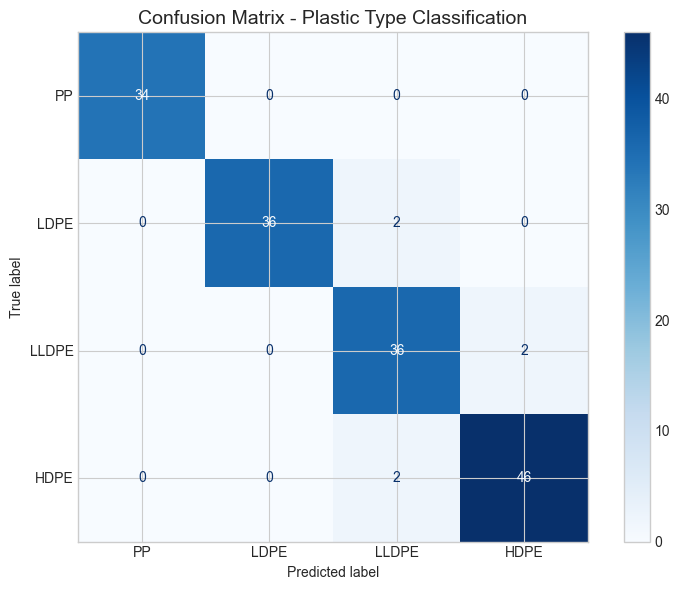

In [14]:
# Confusion matrix for plastic type
cm_plastic = confusion_matrix(y_plastic_test, y_plastic_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_plastic, display_labels=PLASTIC_TYPES)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix - Plastic Type Classification', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_plastic_confusion_matrix.png', dpi=150)
plt.show()

In [15]:
# Cross-validation for plastic type model
print("Performing 5-fold Cross-Validation for Plastic Type Model...")
cv_scores_plastic = cross_val_score(
    lr_plastic, 
    X_train_scaled, 
    y_plastic_train, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy'
)

print(f"\nCross-validation scores: {cv_scores_plastic}")
print(f"Mean CV accuracy: {cv_scores_plastic.mean():.4f} (+/- {cv_scores_plastic.std() * 2:.4f})")

Performing 5-fold Cross-Validation for Plastic Type Model...


c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning


Cross-validation scores: [0.95238095 0.92063492 0.93650794 0.91269841 0.92857143]
Mean CV accuracy: 0.9302 (+/- 0.0273)


## 4. Logistic Regression for Contaminant Detection (Multi-Label)

In [16]:
# Create multi-output logistic regression for contaminant detection
# Using MultiOutputClassifier wrapper for multi-label classification
base_lr = LogisticRegression(
    solver='newton-cg',
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=100.0  # Regularization strength
)

lr_contaminant = MultiOutputClassifier(base_lr, n_jobs=-1)

print("Training Multi-Output Logistic Regression for Contaminant Detection...")
lr_contaminant.fit(X_train_scaled, y_contaminant_train)
print("Training complete!")

Training Multi-Output Logistic Regression for Contaminant Detection...
Training complete!


In [17]:
# Predictions on test set
y_contaminant_pred = lr_contaminant.predict(X_test_scaled)

# Evaluate contaminant detection
print("=" * 60)
print("CONTAMINANT DETECTION RESULTS (Multi-Label)")
print("=" * 60)

# Hamming loss (fraction of incorrectly predicted labels)
h_loss = hamming_loss(y_contaminant_test, y_contaminant_pred)
print(f"\nHamming Loss: {h_loss:.4f}")

# Exact match ratio (subset accuracy)
exact_match = accuracy_score(y_contaminant_test, y_contaminant_pred)
print(f"Exact Match Ratio (Subset Accuracy): {exact_match:.4f}")

# Per-label metrics
print("\nPer-Contaminant Performance:")
print("-" * 50)
for i, contaminant in enumerate(CONTAMINANTS):
    acc = accuracy_score(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    f1 = f1_score(y_contaminant_test[:, i], y_contaminant_pred[:, i], zero_division=0)
    print(f"{contaminant:10s}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")

CONTAMINANT DETECTION RESULTS (Multi-Label)

Hamming Loss: 0.0158
Exact Match Ratio (Subset Accuracy): 0.9241

Per-Contaminant Performance:
--------------------------------------------------
BSA       : Accuracy = 1.0000, F1-Score = 1.0000
Oil       : Accuracy = 0.9937, F1-Score = 0.9928
Starch    : Accuracy = 0.9747, F1-Score = 0.9722
CMC       : Accuracy = 0.9494, F1-Score = 0.9420
Guar      : Accuracy = 0.9873, F1-Score = 0.9859
Casein    : Accuracy = 1.0000, F1-Score = 1.0000


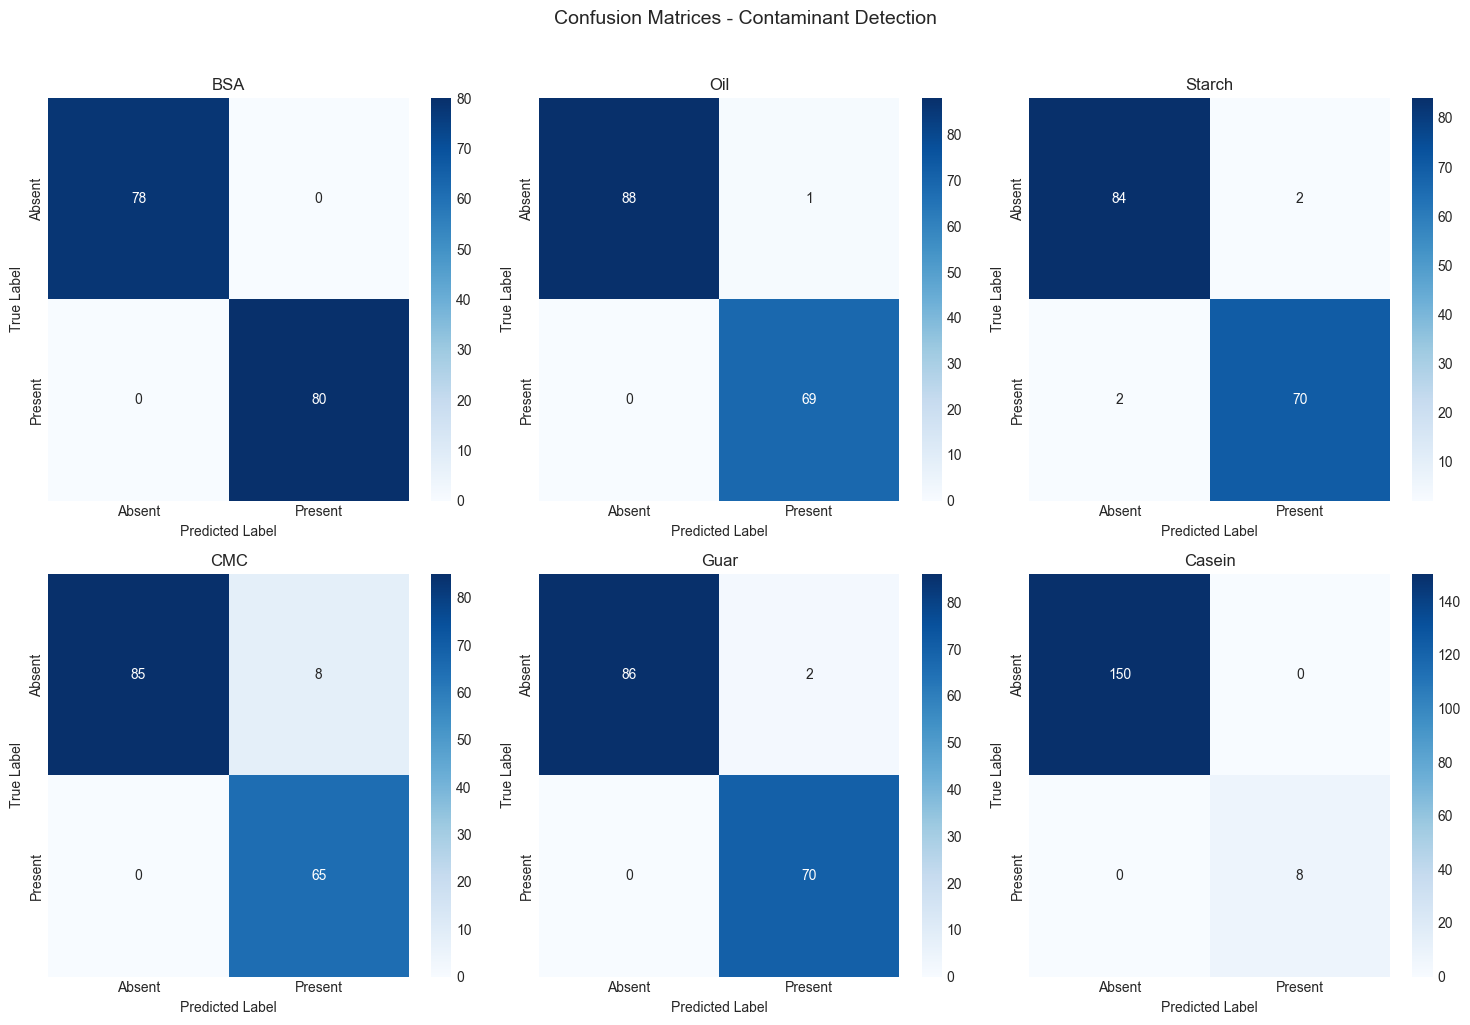

In [18]:
# Confusion matrices for each contaminant
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    cm = confusion_matrix(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Absent', 'Present'],
                yticklabels=['Absent', 'Present'])
    ax.set_title(f'{contaminant}', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices - Contaminant Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_contaminant_confusion_matrices.png', dpi=150)
plt.show()

c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


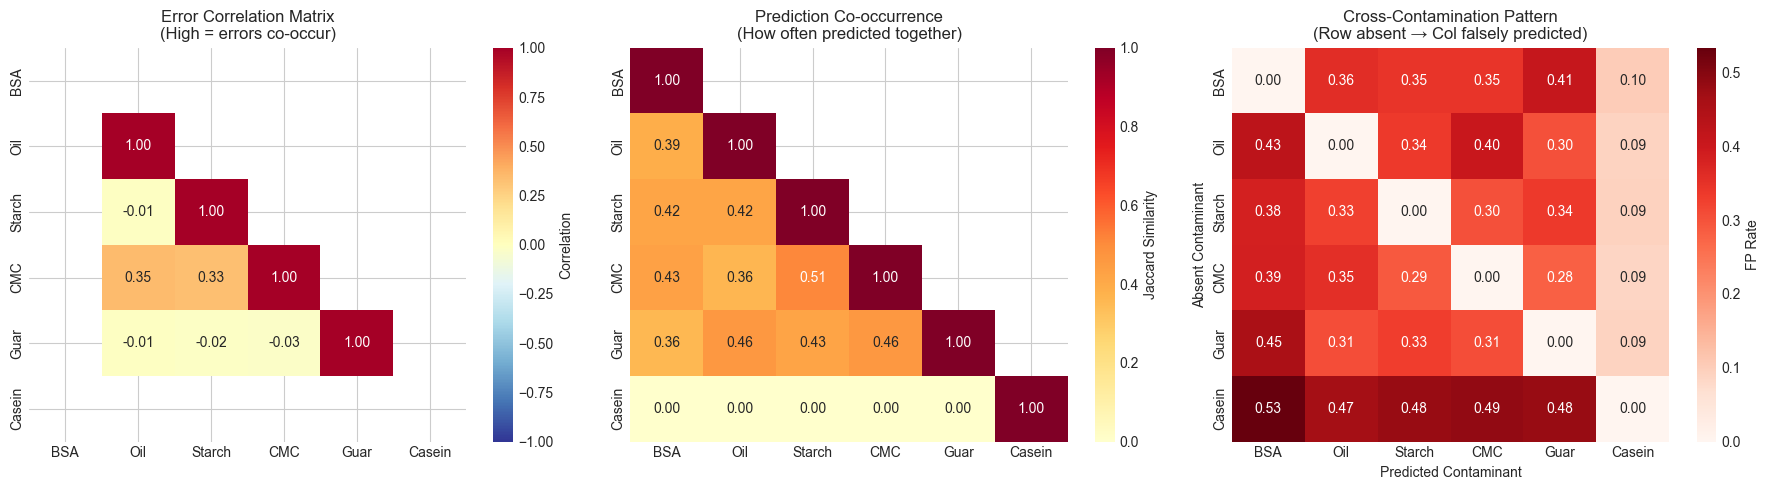


Most correlated error pairs (contaminants often misclassified together):
------------------------------------------------------------
  Oil <-> CMC: correlation = 0.346
  Starch <-> CMC: correlation = 0.330
  CMC <-> Guar: correlation = -0.026
  Starch <-> Guar: correlation = -0.018
  Oil <-> Starch: correlation = -0.013


In [19]:
# Analyze which contaminants are difficult to differentiate from each other
# Using pairwise error correlation and prediction similarity

# 1. Compute error vectors (1 = incorrect prediction, 0 = correct)
errors = (y_contaminant_test != y_contaminant_pred).astype(int)

# 2. Compute pairwise error correlation matrix
# High correlation means when one contaminant is misclassified, the other often is too
error_corr = np.corrcoef(errors.T)

# 3. Compute prediction similarity matrix (Jaccard similarity of predicted labels)
pred_similarity = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)))
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        # How often are both predicted as present together vs. at least one present
        both_present = np.sum((y_contaminant_pred[:, i] == 1) & (y_contaminant_pred[:, j] == 1))
        either_present = np.sum((y_contaminant_pred[:, i] == 1) | (y_contaminant_pred[:, j] == 1))
        pred_similarity[i, j] = both_present / either_present if either_present > 0 else 0

# 4. Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Error correlation matrix
mask1 = np.triu(np.ones_like(error_corr, dtype=bool), k=1)
sns.heatmap(error_corr, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[0], vmin=-1, vmax=1, mask=mask1,
            cbar_kws={'label': 'Correlation'})
axes[0].set_title('Error Correlation Matrix\n(High = errors co-occur)', fontsize=12)

# Plot 2: Prediction similarity (Jaccard)
mask2 = np.triu(np.ones_like(pred_similarity, dtype=bool), k=1)
sns.heatmap(pred_similarity, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[1], vmin=0, vmax=1, mask=mask2,
            cbar_kws={'label': 'Jaccard Similarity'})
axes[1].set_title('Prediction Co-occurrence\n(How often predicted together)', fontsize=12)

# Plot 3: Confusion pattern - False positive rates when each contaminant is truly absent
fp_when_absent = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)))
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        if i != j:
            # When contaminant i is truly absent, how often is j falsely predicted?
            i_absent = y_contaminant_test[:, i] == 0
            if np.sum(i_absent) > 0:
                fp_when_absent[i, j] = np.mean(y_contaminant_pred[i_absent, j])

sns.heatmap(fp_when_absent, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[2], vmin=0,
            cbar_kws={'label': 'FP Rate'})
axes[2].set_title('Cross-Contamination Pattern\n(Row absent → Col falsely predicted)', fontsize=12)
axes[2].set_xlabel('Predicted Contaminant')
axes[2].set_ylabel('Absent Contaminant')

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_contaminant_confusion_analysis.png', dpi=150)
plt.show()

# Print summary of most confused pairs
print("\nMost correlated error pairs (contaminants often misclassified together):")
print("-" * 60)
error_pairs = []
for i in range(len(CONTAMINANTS)):
    for j in range(i+1, len(CONTAMINANTS)):
        if not np.isnan(error_corr[i, j]):
            error_pairs.append((CONTAMINANTS[i], CONTAMINANTS[j], error_corr[i, j]))

error_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, corr in error_pairs[:5]:
    print(f"  {c1} <-> {c2}: correlation = {corr:.3f}")

## 4.1 Hyperparameter Tuning with Grid Search

In [20]:
from sklearn.model_selection import GridSearchCV

# ============================================================================
# Grid Search for Plastic Type Classification Model
# ============================================================================

"""


print("=" * 60)
print("GRID SEARCH: Plastic Type Classification")
print("=" * 60)

# Define parameter grid for plastic type model
param_grid_plastic = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'newton-cg', 'sag'],
    'penalty': ['l2'],
    'max_iter': [5000]
}

# Create base model
lr_plastic_base = LogisticRegression(
    multi_class='multinomial',
    random_state=RANDOM_STATE
)

# Run grid search
grid_search_plastic = GridSearchCV(
    lr_plastic_base,
    param_grid_plastic,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nSearching for best parameters...")
grid_search_plastic.fit(X_train_scaled, y_plastic_train)

print(f"\nBest parameters: {grid_search_plastic.best_params_}")
print(f"Best CV accuracy: {grid_search_plastic.best_score_:.4f}")

# Evaluate best model on test set
best_lr_plastic = grid_search_plastic.best_estimator_
y_plastic_pred_tuned = best_lr_plastic.predict(X_test_scaled)
accuracy_plastic_tuned = accuracy_score(y_plastic_test, y_plastic_pred_tuned)
print(f"Test accuracy with tuned model: {accuracy_plastic_tuned:.4f}")
print(f"Improvement over default: {(accuracy_plastic_tuned - accuracy_plastic)*100:+.2f}%")


"""


'\n\n\nprint("=" * 60)\nprint("GRID SEARCH: Plastic Type Classification")\nprint("=" * 60)\n\n# Define parameter grid for plastic type model\nparam_grid_plastic = {\n    \'C\': [0.01, 0.1, 1.0, 10.0, 100.0],\n    \'solver\': [\'lbfgs\', \'newton-cg\', \'sag\'],\n    \'penalty\': [\'l2\'],\n    \'max_iter\': [5000]\n}\n\n# Create base model\nlr_plastic_base = LogisticRegression(\n    multi_class=\'multinomial\',\n    random_state=RANDOM_STATE\n)\n\n# Run grid search\ngrid_search_plastic = GridSearchCV(\n    lr_plastic_base,\n    param_grid_plastic,\n    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),\n    scoring=\'accuracy\',\n    n_jobs=-1,\n    verbose=1\n)\n\nprint("\nSearching for best parameters...")\ngrid_search_plastic.fit(X_train_scaled, y_plastic_train)\n\nprint(f"\nBest parameters: {grid_search_plastic.best_params_}")\nprint(f"Best CV accuracy: {grid_search_plastic.best_score_:.4f}")\n\n# Evaluate best model on test set\nbest_lr_plastic = grid_search_

In [22]:
# ============================================================================
# Grid Search for Contaminant Detection Model (Multi-Label)
# ============================================================================

"""

print("=" * 60)
print("GRID SEARCH: Contaminant Detection (Multi-Label)")
print("=" * 60)

# Define parameter grid for contaminant model
# For MultiOutputClassifier, parameters are prefixed with 'estimator__'
param_grid_contaminant = {
    'estimator__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'estimator__solver': ['lbfgs', 'newton-cg', 'sag'],
    'estimator__penalty': ['l2'],
    'estimator__max_iter': [1000]
}

# Create base multi-output model
base_lr_contaminant = LogisticRegression(random_state=RANDOM_STATE)
lr_contaminant_multi = MultiOutputClassifier(base_lr_contaminant)

# Run grid search (using hamming loss as negative for minimization)
# We'll use a custom scorer based on accuracy for multi-label
from sklearn.metrics import make_scorer

def multi_label_accuracy(y_true, y_pred):
    #Calculate average accuracy across all labels.
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])

multi_label_scorer = make_scorer(multi_label_accuracy)

grid_search_contaminant = GridSearchCV(
    lr_contaminant_multi,
    param_grid_contaminant,
    cv=5,
    scoring=multi_label_scorer,
    n_jobs=-1,
    verbose=1
)

print("\nSearching for best parameters...")
grid_search_contaminant.fit(X_train_scaled, y_contaminant_train)

print(f"\nBest parameters: {grid_search_contaminant.best_params_}")
print(f"Best CV score (avg label accuracy): {grid_search_contaminant.best_score_:.4f}")

# Evaluate best model on test set
best_lr_contaminant = grid_search_contaminant.best_estimator_
y_contaminant_pred_tuned = best_lr_contaminant.predict(X_test_scaled)
h_loss_tuned = hamming_loss(y_contaminant_test, y_contaminant_pred_tuned)
exact_match_tuned = accuracy_score(y_contaminant_test, y_contaminant_pred_tuned)
print(f"\nTest Hamming Loss with tuned model: {h_loss_tuned:.4f}")
print(f"Test Exact Match Ratio with tuned model: {exact_match_tuned:.4f}")
print(f"Hamming Loss improvement: {(h_loss - h_loss_tuned)*100:+.4f}% (lower is better)")

"""

'\n\nprint("=" * 60)\nprint("GRID SEARCH: Contaminant Detection (Multi-Label)")\nprint("=" * 60)\n\n# Define parameter grid for contaminant model\n# For MultiOutputClassifier, parameters are prefixed with \'estimator__\'\nparam_grid_contaminant = {\n    \'estimator__C\': [0.01, 0.1, 1.0, 10.0, 100.0],\n    \'estimator__solver\': [\'lbfgs\', \'newton-cg\', \'sag\'],\n    \'estimator__penalty\': [\'l2\'],\n    \'estimator__max_iter\': [1000]\n}\n\n# Create base multi-output model\nbase_lr_contaminant = LogisticRegression(random_state=RANDOM_STATE)\nlr_contaminant_multi = MultiOutputClassifier(base_lr_contaminant)\n\n# Run grid search (using hamming loss as negative for minimization)\n# We\'ll use a custom scorer based on accuracy for multi-label\nfrom sklearn.metrics import make_scorer\n\ndef multi_label_accuracy(y_true, y_pred):\n    #Calculate average accuracy across all labels.\n    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])\n\nmulti_l

In [23]:
# ============================================================================
# Visualize Grid Search Results
# ============================================================================

"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Plastic Type Grid Search Results
cv_results_plastic = pd.DataFrame(grid_search_plastic.cv_results_)
pivot_plastic = cv_results_plastic.pivot_table(
    values='mean_test_score', 
    index='param_C', 
    columns='param_solver'
)
sns.heatmap(pivot_plastic, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'CV Accuracy'})
axes[0].set_title('Plastic Type Model - Grid Search Results', fontsize=12)
axes[0].set_xlabel('Solver')
axes[0].set_ylabel('C (Regularization)')

# Plot 2: Contaminant Detection Grid Search Results
cv_results_contaminant = pd.DataFrame(grid_search_contaminant.cv_results_)
pivot_contaminant = cv_results_contaminant.pivot_table(
    values='mean_test_score', 
    index='param_estimator__C', 
    columns='param_estimator__solver'
)
sns.heatmap(pivot_contaminant, annot=True, fmt='.3f', cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'CV Avg Label Accuracy'})
axes[1].set_title('Contaminant Detection - Grid Search Results', fontsize=12)
axes[1].set_xlabel('Solver')
axes[1].set_ylabel('C (Regularization)')

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_grid_search_results.png', dpi=150)
plt.show()

# Summary
print("\n" + "=" * 60)
print("GRID SEARCH SUMMARY")
print("=" * 60)
print(f"\nPlastic Type Classification:")
print(f"  Best params: C={grid_search_plastic.best_params_['C']}, solver={grid_search_plastic.best_params_['solver']}")
print(f"  Default accuracy: {accuracy_plastic:.4f} → Tuned accuracy: {accuracy_plastic_tuned:.4f}")

print(f"\nContaminant Detection:")
print(f"  Best params: C={grid_search_contaminant.best_params_['estimator__C']}, solver={grid_search_contaminant.best_params_['estimator__solver']}")
print(f"  Default Hamming Loss: {h_loss:.4f} → Tuned Hamming Loss: {h_loss_tuned:.4f}")

"""

'\n\nfig, axes = plt.subplots(1, 2, figsize=(14, 5))\n\n# Plot 1: Plastic Type Grid Search Results\ncv_results_plastic = pd.DataFrame(grid_search_plastic.cv_results_)\npivot_plastic = cv_results_plastic.pivot_table(\n    values=\'mean_test_score\', \n    index=\'param_C\', \n    columns=\'param_solver\'\n)\nsns.heatmap(pivot_plastic, annot=True, fmt=\'.3f\', cmap=\'Blues\', ax=axes[0],\n            cbar_kws={\'label\': \'CV Accuracy\'})\naxes[0].set_title(\'Plastic Type Model - Grid Search Results\', fontsize=12)\naxes[0].set_xlabel(\'Solver\')\naxes[0].set_ylabel(\'C (Regularization)\')\n\n# Plot 2: Contaminant Detection Grid Search Results\ncv_results_contaminant = pd.DataFrame(grid_search_contaminant.cv_results_)\npivot_contaminant = cv_results_contaminant.pivot_table(\n    values=\'mean_test_score\', \n    index=\'param_estimator__C\', \n    columns=\'param_estimator__solver\'\n)\nsns.heatmap(pivot_contaminant, annot=True, fmt=\'.3f\', cmap=\'Greens\', ax=axes[1],\n            cbar

## 5. Combined Multi-Output Model

In [24]:
# Create combined labels (plastic type + contaminants)
# Plastic type as integer class (0-3) + contaminant binary labels
y_combined_train = np.column_stack([y_plastic_train.reshape(-1, 1), y_contaminant_train])
y_combined_test = np.column_stack([y_plastic_test.reshape(-1, 1), y_contaminant_test])

print(f"Combined labels shape (train): {y_combined_train.shape}")
print(f"Combined labels shape (test): {y_combined_test.shape}")
print(f"\nOutput dimensions:")
print(f"  Column 0: Plastic type (0={PLASTIC_TYPES[0]}, 1={PLASTIC_TYPES[1]}, 2={PLASTIC_TYPES[2]}, 3={PLASTIC_TYPES[3]})")
for i, cont in enumerate(CONTAMINANTS):
    print(f"  Column {i+1}: {cont} (0=absent, 1=present)")

Combined labels shape (train): (630, 7)
Combined labels shape (test): (158, 7)

Output dimensions:
  Column 0: Plastic type (0=PP, 1=LDPE, 2=LLDPE, 3=HDPE)
  Column 1: BSA (0=absent, 1=present)
  Column 2: Oil (0=absent, 1=present)
  Column 3: Starch (0=absent, 1=present)
  Column 4: CMC (0=absent, 1=present)
  Column 5: Guar (0=absent, 1=present)
  Column 6: Casein (0=absent, 1=present)


In [25]:
# Train combined multi-output model
base_lr_combined = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    random_state=RANDOM_STATE,
    C=100.0  # Regularization strength
)

lr_combined = MultiOutputClassifier(base_lr_combined, n_jobs=-1)

print("Training Combined Multi-Output Logistic Regression Model...")
lr_combined.fit(X_train_scaled, y_combined_train)
print("Training complete!")

# Predictions
y_combined_pred = lr_combined.predict(X_test_scaled)

Training Combined Multi-Output Logistic Regression Model...


Training complete!


In [26]:
# Evaluate combined model
print("=" * 60)
print("COMBINED MODEL RESULTS")
print("=" * 60)

# Plastic type (first column)
plastic_acc_combined = accuracy_score(y_combined_test[:, 0], y_combined_pred[:, 0])
print(f"\nPlastic Type Accuracy: {plastic_acc_combined:.4f}")

# Contaminants (remaining columns)
contaminant_h_loss = hamming_loss(y_combined_test[:, 1:], y_combined_pred[:, 1:])
print(f"Contaminant Hamming Loss: {contaminant_h_loss:.4f}")

# Overall exact match ratio - computed manually since accuracy_score doesn't support multiclass-multioutput
# Check if ALL outputs match for each sample
overall_exact_match = np.all(y_combined_test == y_combined_pred, axis=1).mean()
print(f"Overall Exact Match Ratio: {overall_exact_match:.4f}")

COMBINED MODEL RESULTS

Plastic Type Accuracy: 0.9620
Contaminant Hamming Loss: 0.0179
Overall Exact Match Ratio: 0.8861


## 6. Save Model and Results

In [27]:
import joblib
from datetime import datetime

# Create output directories if they don't exist
models_dir = Path('.').resolve()
reports_dir = project_root / 'reports' / 'text_reports'
figures_dir = project_root / 'reports' / 'figures'

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Save models
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

joblib.dump(lr_plastic, models_dir / f'lr_plastic_model_{timestamp}.joblib')
joblib.dump(lr_contaminant, models_dir / f'lr_contaminant_model_{timestamp}.joblib')
joblib.dump(lr_combined, models_dir / f'lr_combined_model_{timestamp}.joblib')
joblib.dump(scaler, models_dir / f'scaler_{timestamp}.joblib')

print(f"Models saved to: {models_dir}")

Models saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\src\models\logistic_regression


In [28]:
# Generate and save text report
report = f"""
================================================================================
LOGISTIC REGRESSION MODEL EVALUATION REPORT
================================================================================
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Data: IR Spectral Data
Training samples: {X_train.shape[0]}
Test samples: {X_test.shape[0]}
Features: {X_train.shape[1]} (wavenumber points)

--------------------------------------------------------------------------------
1. PLASTIC TYPE CLASSIFICATION (Multi-class)
--------------------------------------------------------------------------------
Classes: {PLASTIC_TYPES}
Test Accuracy: {accuracy_plastic:.4f}
Mean CV Accuracy: {cv_scores_plastic.mean():.4f} (+/- {cv_scores_plastic.std() * 2:.4f})

{classification_report(y_plastic_test, y_plastic_pred, target_names=PLASTIC_TYPES)}

--------------------------------------------------------------------------------
2. CONTAMINANT DETECTION (Multi-label)
--------------------------------------------------------------------------------
Contaminants: {CONTAMINANTS}
Hamming Loss: {h_loss:.4f}
Exact Match Ratio: {exact_match:.4f}

Per-contaminant Performance:
"""

for i, contaminant in enumerate(CONTAMINANTS):
    acc = accuracy_score(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    f1 = f1_score(y_contaminant_test[:, i], y_contaminant_pred[:, i], zero_division=0)
    report += f"  {contaminant}: Accuracy={acc:.4f}, F1-Score={f1:.4f}\n"

report += f"""
--------------------------------------------------------------------------------
3. COMBINED MODEL
--------------------------------------------------------------------------------
Plastic Type Accuracy: {plastic_acc_combined:.4f}
Contaminant Hamming Loss: {contaminant_h_loss:.4f}
Overall Exact Match Ratio: {overall_exact_match:.4f}

================================================================================
"""

# Save report
report_path = reports_dir / f'lr_evaluation_report_{timestamp}.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print(f"\nReport saved to: {report_path}")


LOGISTIC REGRESSION MODEL EVALUATION REPORT
Date: 2026-01-11 17:16:57
Data: IR Spectral Data
Training samples: 630
Test samples: 158
Features: 7469 (wavenumber points)

--------------------------------------------------------------------------------
1. PLASTIC TYPE CLASSIFICATION (Multi-class)
--------------------------------------------------------------------------------
Classes: ['PP', 'LDPE', 'LLDPE', 'HDPE']
Test Accuracy: 0.9620
Mean CV Accuracy: 0.9302 (+/- 0.0273)

              precision    recall  f1-score   support

          PP       1.00      1.00      1.00        34
        LDPE       1.00      0.95      0.97        38
       LLDPE       0.90      0.95      0.92        38
        HDPE       0.96      0.96      0.96        48

    accuracy                           0.96       158
   macro avg       0.96      0.96      0.96       158
weighted avg       0.96      0.96      0.96       158


--------------------------------------------------------------------------------
2. C

## 7. Model Coefficients Analysis

C:\Users\Mikey\AppData\Local\Temp\ipykernel_29948\1589818314.py:18: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_29948\1589818314.py:19: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_coefficients_plastic.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


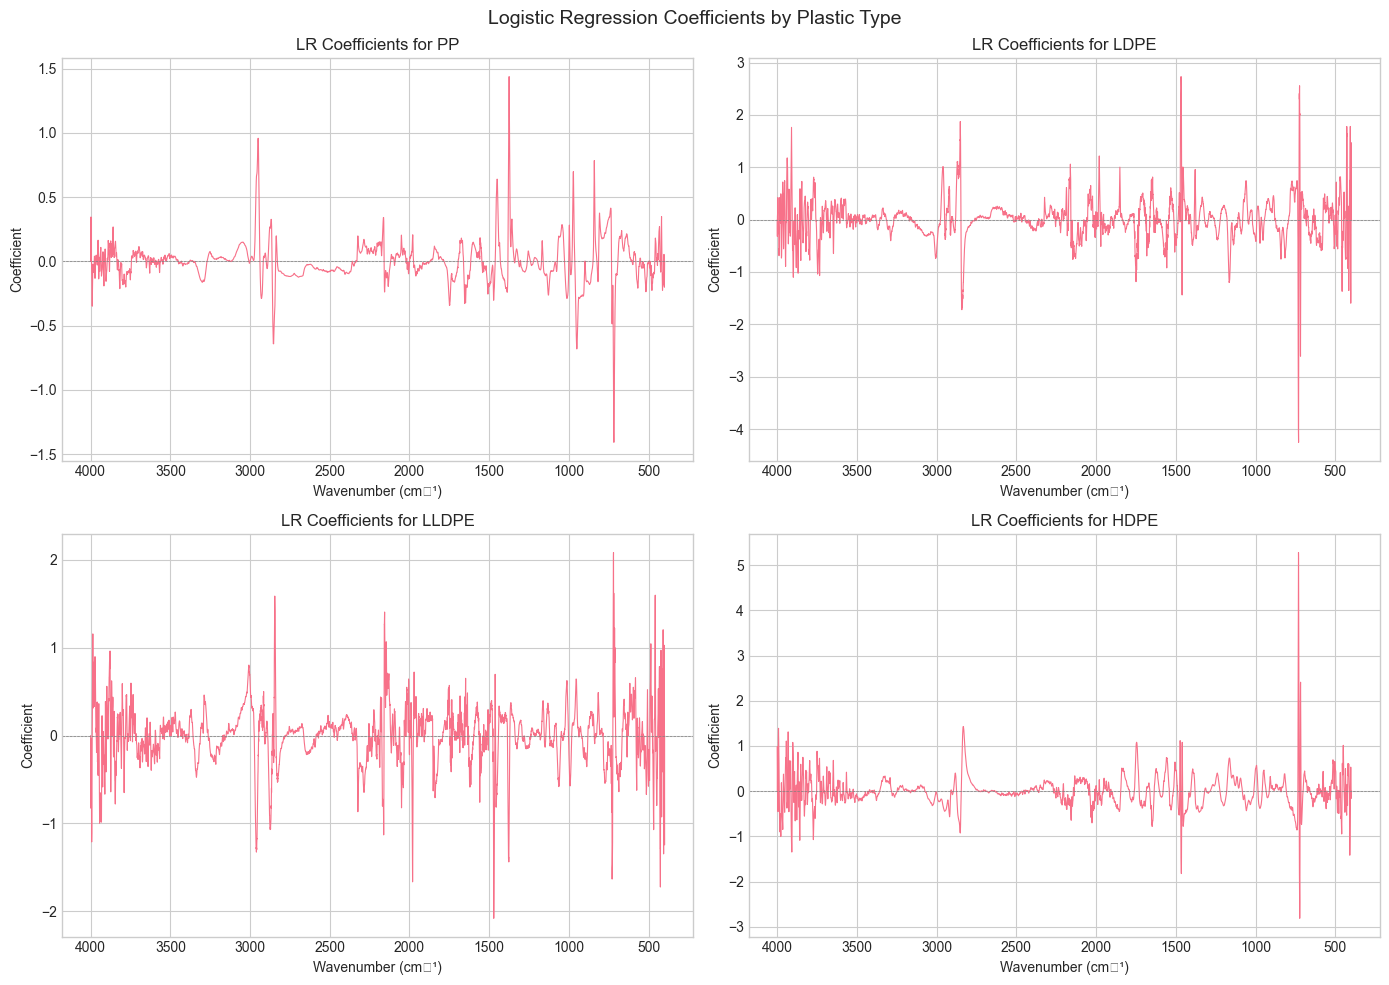


TOP 20 MOST IMPORTANT FEATURES BY PLASTIC TYPE

PP:
------------------------------------------------------------
 Rank Wavenumber (cm⁻¹) Coefficient Direction
    1            1375.0      1.4381  Positive
    2            1374.5      1.4220  Positive
    3             717.9     -1.4076  Negative
    4             717.4     -1.4020  Negative
    5            1375.5      1.3883  Positive
    6             718.4     -1.3817  Negative
    7            1374.1      1.3800  Positive
    8             716.9     -1.3642  Negative
    9             718.8     -1.3228  Negative
   10            1373.6      1.3167  Positive
   11            1376.0      1.3152  Positive
   12             716.4     -1.3037  Negative
   13            1373.1      1.2399  Positive
   14             719.3     -1.2321  Negative
   15             716.0     -1.2267  Negative
   16            1376.5      1.2231  Positive
   17             715.5     -1.1392  Negative
   18            1372.6      1.1324  Positive
   19       

In [29]:
# Visualize logistic regression coefficients for plastic type model
# This shows which wavenumbers are most important for classification

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (ax, plastic) in enumerate(zip(axes, PLASTIC_TYPES)):
    coefficients = lr_plastic.coef_[i]
    
    ax.plot(wavenumbers, coefficients, linewidth=0.8)
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Coefficient', fontsize=10)
    ax.set_title(f'LR Coefficients for {plastic}', fontsize=12)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.invert_xaxis()  # IR spectra convention

plt.suptitle('Logistic Regression Coefficients by Plastic Type', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_coefficients_plastic.png', dpi=150)
plt.show()

# Create table of top 20 most important features for each plastic type
print("\n" + "=" * 80)
print("TOP 20 MOST IMPORTANT FEATURES BY PLASTIC TYPE")
print("=" * 80)

for i, plastic in enumerate(PLASTIC_TYPES):
    coefficients = lr_plastic.coef_[i]
    
    # Get indices sorted by absolute coefficient value (descending)
    top_indices = np.argsort(np.abs(coefficients))[::-1][:20]
    
    # Create DataFrame for display
    top_features_df = pd.DataFrame({
        'Rank': range(1, 21),
        'Wavenumber (cm⁻¹)': [f"{wavenumbers[idx]:.1f}" for idx in top_indices],
        'Coefficient': [f"{coefficients[idx]:.4f}" for idx in top_indices],
        'Direction': ['Positive' if coefficients[idx] > 0 else 'Negative' for idx in top_indices]
    })
    
    print(f"\n{plastic}:")
    print("-" * 60)
    print(top_features_df.to_string(index=False))

C:\Users\Mikey\AppData\Local\Temp\ipykernel_29948\2921579305.py:19: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_29948\2921579305.py:20: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_coefficients_contaminant.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


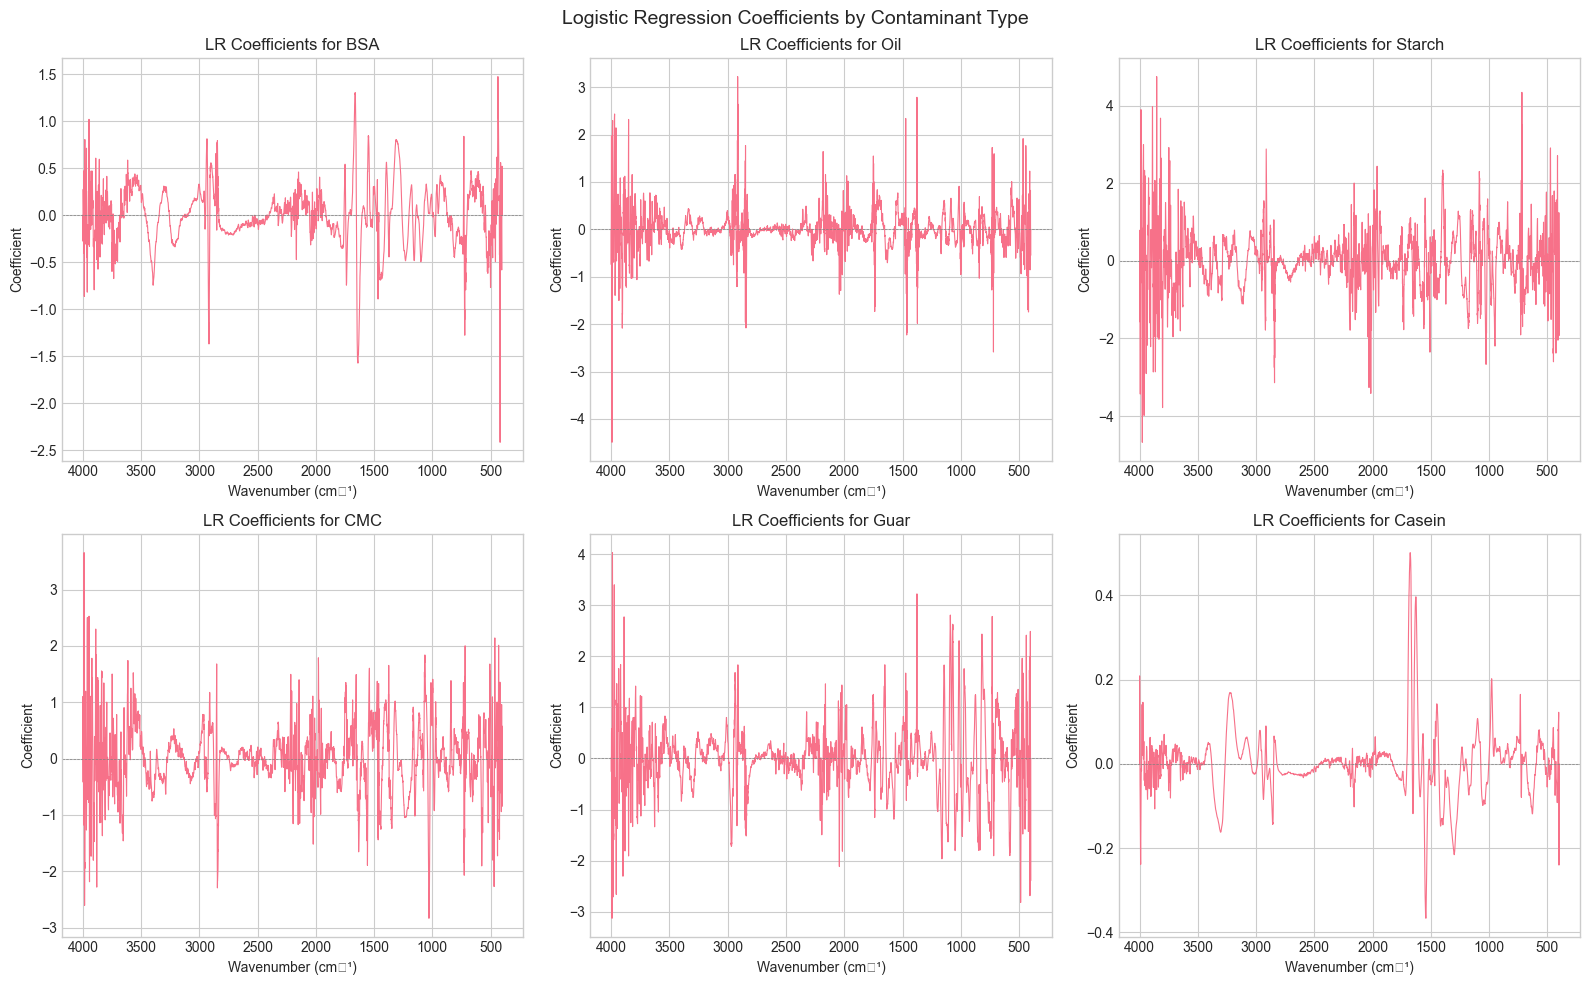

In [30]:
# Visualize logistic regression coefficients for contaminant detection model
# This shows which wavenumbers are most important for detecting each contaminant

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    # Each estimator in MultiOutputClassifier has coef_ for binary classification
    coefficients = lr_contaminant.estimators_[i].coef_[0]
    
    ax.plot(wavenumbers, coefficients, linewidth=0.8)
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Coefficient', fontsize=10)
    ax.set_title(f'LR Coefficients for {contaminant}', fontsize=12)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.invert_xaxis()  # IR spectra convention

plt.suptitle('Logistic Regression Coefficients by Contaminant Type', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_coefficients_contaminant.png', dpi=150)
plt.show()

In [31]:
print("Logistic Regression model training and evaluation complete!")
print(f"\nSummary:")
print(f"  - Plastic Type Classification Accuracy: {accuracy_plastic:.2%}")
print(f"  - Contaminant Detection Hamming Loss: {h_loss:.4f}")
print(f"  - Models saved to: {models_dir}")
print(f"  - Reports saved to: {reports_dir}")
print(f"  - Figures saved to: {figures_dir}")

Logistic Regression model training and evaluation complete!

Summary:
  - Plastic Type Classification Accuracy: 96.20%
  - Contaminant Detection Hamming Loss: 0.0158
  - Models saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\src\models\logistic_regression
  - Reports saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\text_reports
  - Figures saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\figures
